### Parameter estimation of LVK event GW250114

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

import numpy as np
import matplotlib.pyplot as plt
import bilby
from gwpy.timeseries import TimeSeries

/opt/anaconda3/envs/qnm_filter/lib/python3.11/site-packages/bilby/core/likelihood.py:7: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.special import gammaln, xlogy


In [2]:
#gps time of the event we are interested to anlyze
time_of_event = 1420878141.2 

In [3]:
# setting up empty interferometers

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

In [4]:
# For defining a portion of the data with respect to the trigger time (time_of_event)

post_trigger_duration = 2 #it is a standard choice
duration = 4  

analysis_start = time_of_event + post_trigger_duration - duration 
# 4second window, with 2 seconds pre and post-trigger

In [5]:
# Using gwpy and fetching the open data

H1_analysis_data = TimeSeries.fetch_open_data(
    "H1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True)  #4096 is standard choice

L1_analysis_data = TimeSeries.fetch_open_data(
    "L1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True)

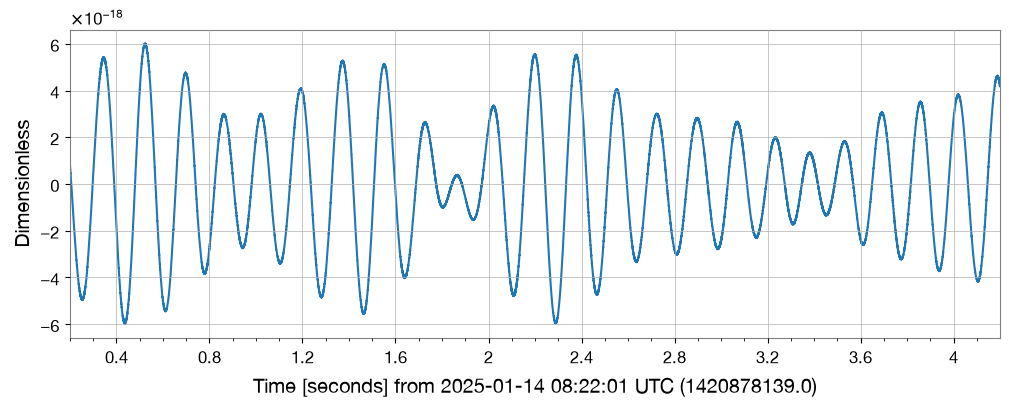

In [6]:
H1_analysis_data.plot()
plt.show()

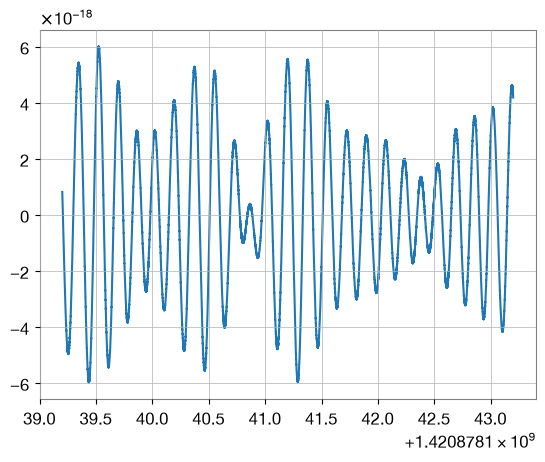

In [7]:
#Another way of plotting 

plt.plot(H1_analysis_data.times.value, H1_analysis_data.value)

In [8]:
# We pass the downloaded strain data to the H1 and L1 Bilby interferometer objects.
H1.set_strain_data_from_gwpy_timeseries(H1_analysis_data)
L1.set_strain_data_from_gwpy_timeseries(L1_analysis_data)

In [9]:
# We require the noise properties of the data. 
#We will create a PSD using the off-source data that is close to the event. Preceding the event.

psd_duration = duration * 32  #32 times tha anlaysis-portion
psd_start_time = analysis_start - psd_duration


# we fetch this data 
H1_psd_data = TimeSeries.fetch_open_data(
    "H1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)

L1_psd_data = TimeSeries.fetch_open_data(
    "L1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)

In [10]:
# Procedure to convert detector data into PSD; detector data is time-series and requires taking an FFT

psd_alpha = 2 * H1.strain_data.roll_off / duration  # to suppress spectral leakage from the segment edges

H1_psd = H1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1_psd = L1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")

Text(0, 0.5, 'window')

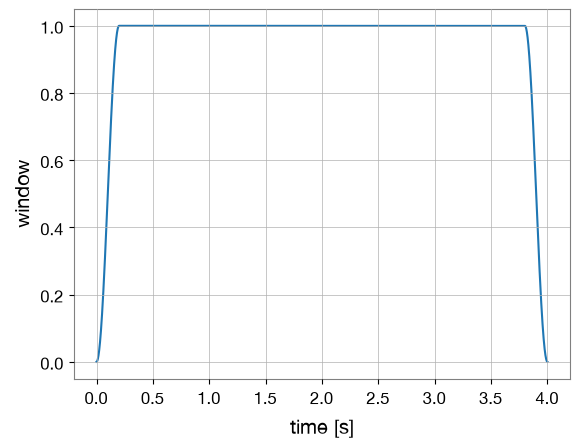

In [11]:
# The role of the taper window is shown. It smooths the edges and makes them go to zero rather than a sharp change

from scipy.signal import get_window
n = int(duration * 4096)
w = get_window(("tukey", psd_alpha), n)
plt.plot(np.linspace(0, duration, n), w)
plt.xlabel('time [s]'); plt.ylabel('window')

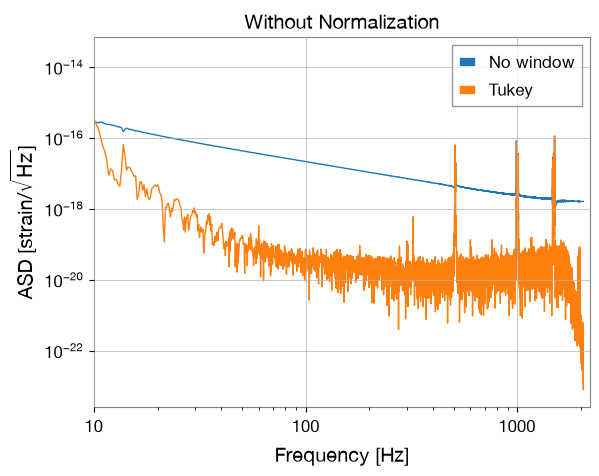

In [12]:
# Once the taper forces both ends to zero, the discontinuity is gone, and the leakage with it (blue)
# This reveals the features we would expect (orange)
d  = H1_analysis_data.value
fs = 4096
N  = len(d)
f  = np.fft.rfftfreq(N, d=1/fs)
norm = np.sqrt(2 / (fs * N))

amplitude       = np.abs(np.fft.rfft(d))     
amplitude_tukey = np.abs(np.fft.rfft(d * w)) 
plt.loglog(f, amplitude,       lw=1, label='No window')
plt.loglog(f, amplitude_tukey, lw=1, label='Tukey')
plt.title('Without Normalization')
plt.xlim(10, 2200)
plt.xlabel('Frequency [Hz]') ; plt.ylabel(r'ASD [strain/$\sqrt{\mathrm{Hz}}$]')
plt.legend(); plt.show()

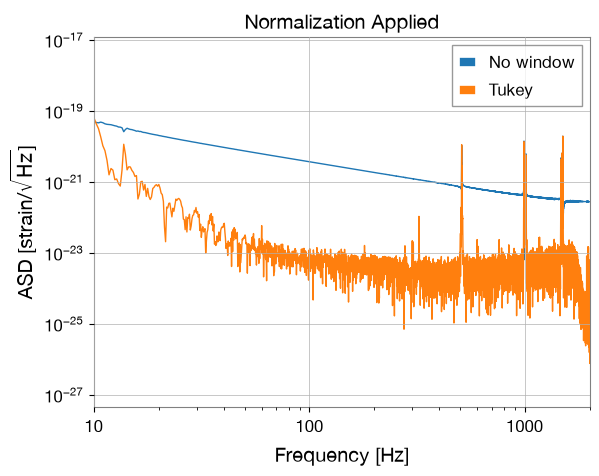

In [13]:
amplitude       = np.abs(np.fft.rfft(d))     * norm
amplitude_tukey = np.abs(np.fft.rfft(d * w)) * norm / np.sqrt(np.mean(w**2))

plt.title('Normalization Applied')
plt.loglog(f, amplitude,       lw=1, label='No window')
plt.loglog(f, amplitude_tukey, lw=1, label='Tukey')
plt.xlim(10, 2000)
plt.xlabel('Frequency [Hz]') ;plt.ylabel(r'ASD [strain/$\sqrt{\mathrm{Hz}}$]')
plt.legend();plt.show()

In [14]:
# We do the above things with Bilby
# Once we have obtained PSD, we overwrite the power_spectal_density attribute with a new PSD.

H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)

L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=L1_psd.value)

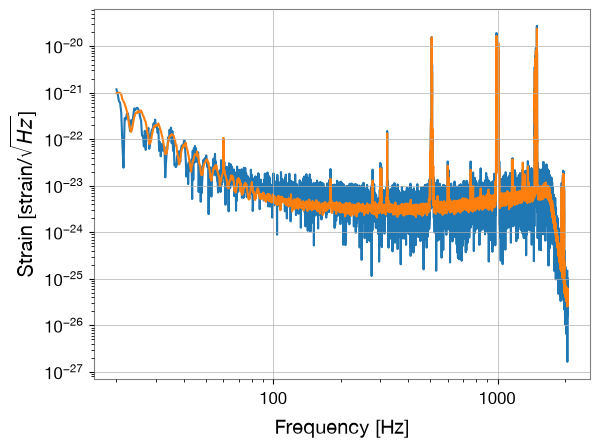

In [15]:

idxs = H1.strain_data.frequency_mask 
# This masks selecting bins b/w minimum and maximum frequency


fig, ax = plt.subplots()

# for the strain, we use what we constructed above
ax.loglog(H1.strain_data.frequency_array[idxs],
          np.abs(H1.strain_data.frequency_domain_strain[idxs]))

# for the noise, we use what we constructed above
ax.loglog(H1.power_spectral_density.frequency_array[idxs],
          H1.power_spectral_density.asd_array[idxs])



ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Strain [strain/$\sqrt{Hz}$]")
plt.show()

In [16]:
# We define the prior. We fix most leaving only chirp mass, mass-ratio and phase here

from bilby.core.prior import Uniform, PowerLaw
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=30.0,maximum=32.5)
prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] =  -1.2232
prior['ra'] =  2.19432
prior['theta_jn'] =  1.89694
prior['psi'] =  0.532268
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')

In [17]:
# First, put our "data" created above into a list of interferometers (the order is arbitrary)
interferometers = [H1, L1]

# Next, create a dictionary of arguments that we pass into the LALSimulation waveform
waveform_arguments = dict(
    waveform_approximant='IMRPhenomXP', reference_frequency=100., catch_waveform_errors=True)

# Next, create a waveform_generator object 
waveform_generator = bilby.gw.WaveformGenerator(
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=waveform_arguments,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters)

# Finally, create our likelihood
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers, waveform_generator, priors=prior,
    time_marginalization=True, phase_marginalization=True, distance_marginalization=True)

14:58 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=None, sampling_frequency=None, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXP', 'reference_frequency': 100.0, 'catch_waveform_errors': True})
14:58 bilby INFO    : Loaded distance marginalisation lookup table does not match for distance_array.
/opt/anaconda3/envs/qnm_filter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:58 bilby INFO    : Building lookup table for distance marginalisation.
100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:11<00:00, 33.42it/s]


In [18]:
result_short = bilby.run_sampler(
    likelihood, prior, sampler='dynesty', outdir='short', label="GW150914",
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    nlive=250, dlogz=1.,  # <- Arguments are used to make things fast - not recommended for general use
    clean=True,
)

14:59 bilby INFO    : Running for label 'GW150914', output will be saved to 'short'
14:59 bilby INFO    : Using lal version 7.7.1
14:59 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.15;Id: 2c00d8c200308422036d0a23b7c0394f7c73faad;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
14:59 bilby INFO    : Using lalsimulation version 6.2.1
14:59 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.15;Id: 2c00d8c200308422036d0a23b7c0394f7c73faad;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
14:59 bilby INFO    : Analysis priors:
14:59 bilby INFO    : chirp_mass=Uniform(minimum=30.0, maximum=32.5, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
14:59 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
14:59 bilby INFO    : time_jitter=Uniform(minimum=np.float64(-0.000244140625), max

764it [00:18,  9.90it/s, bound:0 nc: 42 ncall:5.1e+03 eff:14.9% logz-ratio=247.18+/-0.08 dlogz:1>1]    

14:59 bilby INFO    : Written checkpoint file short/GW150914_resume.pickle


764it [00:19, 39.97it/s, bound:0 nc:  1 ncall:5.4e+03 eff:19.8% logz-ratio=247.81+/-0.10 dlogz:0.00362>1]

14:59 bilby INFO    : Rejection sampling nested samples to obtain 275 posterior samples
14:59 bilby INFO    : Sampling time: 0:00:19.089069
14:59 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
14:59 bilby INFO    : Computing per-detector log likelihoods.


...

14:59 bilby INFO    : Reconstructing marginalised parameters.



100%|███████████████████████████████████████████████████████████████████████████████| 275/275 [00:02<00:00, 103.80it/s]

14:59 bilby INFO    : Computing SNRs for every sample.



100%|███████████████████████████████████████████████████████████████████████████████| 275/275 [00:00<00:00, 313.56it/s]


14:59 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
14:59 bilby INFO    : Summary of results:
nsamples: 275
ln_noise_evidence: -17085.467
ln_evidence: -16837.656 +/-  0.209
ln_bayes_factor: 247.811 +/-  0.209



In [19]:
result_short.posterior

,chirp_mass,mass_ratio,time_jitter,phase,geocent_time,a_1,a_2,tilt_1,tilt_2,phi_12,...,chi_2_in_plane,chi_p,cos_tilt_1,cos_tilt_2,redshift,comoving_distance,mass_1_source,mass_2_source,chirp_mass_source,total_mass_source
0,31.989820,0.774666,-0.000013,2.702988,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.081393,353.319719,38.670779,29.956933,29.582049,68.627712
1,32.465834,0.971286,0.000080,5.884499,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.083381,361.772878,34.929081,33.926130,29.967156,68.855210
2,31.211490,0.754686,-0.000148,2.944894,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.086121,373.414102,38.072933,28.733116,28.736659,66.806049
3,30.785388,0.749237,0.000060,2.864398,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.076855,333.987856,38.017696,28.484246,28.588242,66.501942
4,31.917169,0.907162,-0.000066,2.783441,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.083541,362.453502,35.534139,32.235212,29.456364,67.769352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,31.044808,0.968548,0.000200,2.974964,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.076602,332.908587,33.658163,32.599540,28.835923,66.257702
271,31.097376,0.977834,0.000143,2.794133,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.078227,339.835464,33.503682,32.761052,28.841227,66.264734
272,31.296837,0.980317,0.000093,6.084792,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.080118,347.892148,33.616795,32.955119,28.975391,66.571914
273,31.267252,0.981651,0.000103,5.967539,1.420878e+09,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.082888,359.677809,33.476301,32.862039,28.873954,66.338341


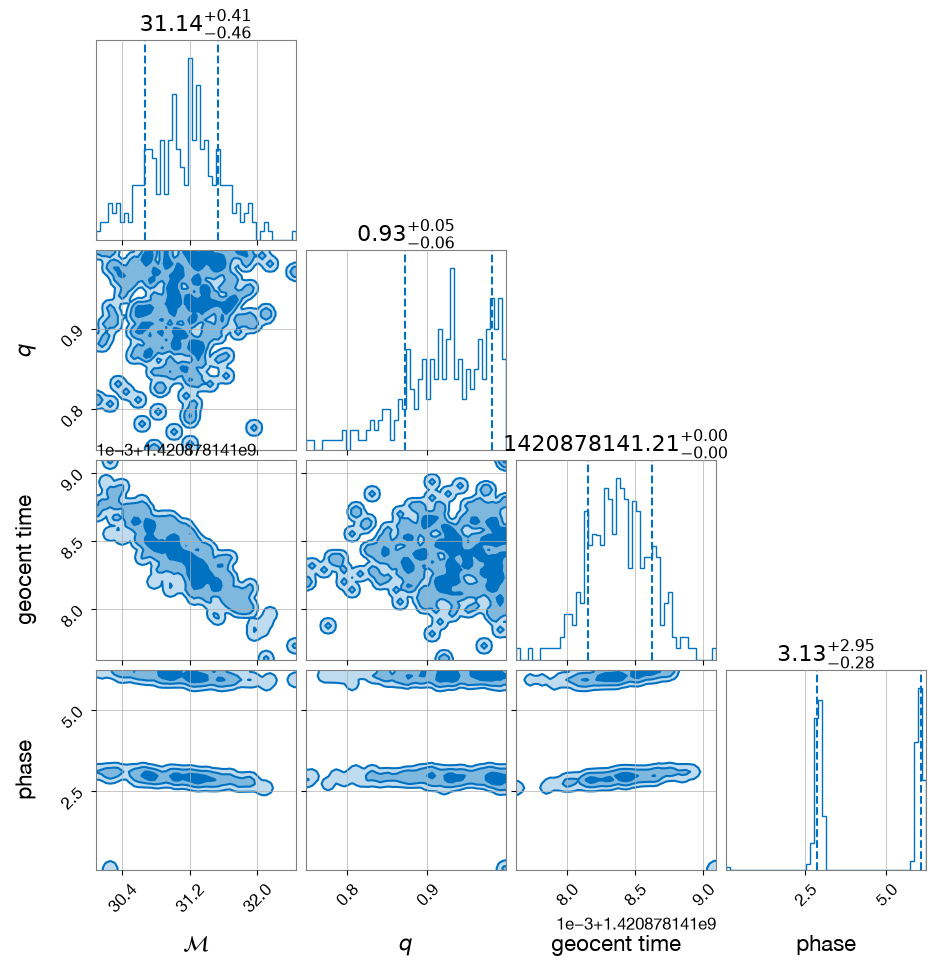

In [20]:
result_short.plot_corner(parameters=["chirp_mass", "mass_ratio", "geocent_time", "phase"], prior=True)


In [21]:
# Working with chirp mass alone
Mchirp = result_short.posterior["chirp_mass"].values

In [22]:
lower_bound = np.quantile(Mchirp, 0.05) #using quantile function
upper_bound = np.quantile(Mchirp, 0.95)
median = np.quantile(Mchirp, 0.5)
print("Mc = {} with a 90% C.I = {} -> {}".format(median, lower_bound, upper_bound))

Mc = 31.136772713600177 with a 90% C.I = 30.367592577321034 -> 31.827194080306025


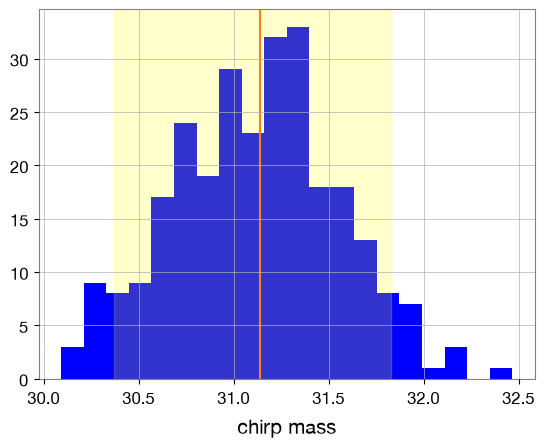

In [23]:
plt.hist(Mchirp, color='blue', bins=20)
plt.axvspan(lower_bound, upper_bound, color='yellow', alpha=0.2)
plt.axvline(median, color='C1')
plt.xlabel("chirp mass")
plt.show()

In [24]:
# full 15-d prior can be directly imported from Bilby and used

prior = bilby.gw.prior.BBHPriorDict()
prior['geocent_time'] = Uniform(minimum=time_of_event-0.1, maximum=time_of_event+0.1)

#or 11-d one
prior = bilby.gw.prior.BBHPriorDict(aligned_spin=True)



14:59 bilby INFO    : No prior given, using default BBH priors in /opt/anaconda3/envs/qnm_filter/lib/python3.11/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.
14:59 bilby INFO    : Using aligned spin prior
14:59 bilby INFO    : No prior given, using default BBH priors in /opt/anaconda3/envs/qnm_filter/lib/python3.11/site-packages/bilby/gw/prior_files/aligned_spins_bbh.prior.
